In [10]:
# Cell 1: Import libraries and generate motor temperature data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from datetime import datetime, timedelta

print("✅ Libraries imported")

# Generate 7 days of motor temperature data (readings every 10 minutes)
np.random.seed(42)

# 7 days × 24 hours × 6 readings/hour = 1008 readings
n_readings = 7 * 24 * 6  # 1008
timestamps = [datetime(2025, 5, 12, 0, 0, 0) + timedelta(minutes=10*i) 
              for i in range(n_readings)]

# Base temperature with daily cycle (warmer during day)
hour_of_day = [ts.hour + ts.minute/60 for ts in timestamps]
base_temp = 65 + 10 * np.sin(np.pi * (np.array(hour_of_day) - 6) / 12)

# Add random noise and some anomalies
noise = np.random.normal(0, 2, n_readings)
anomalies = np.random.choice([0, np.random.normal(15, 3)], 
                              size=n_readings, p=[0.97, 0.03])

temperature = base_temp + noise + anomalies

# Create DataFrame
df = pd.DataFrame({
    'timestamp': timestamps,
    'temperature_c': temperature,
    'hour': hour_of_day,
    'day': [ts.day for ts in timestamps]
})

print(f"✅ Generated {len(df):,} temperature readings over 7 days")
print(f"   Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"   Temperature range: {df['temperature_c'].min():.1f}°C to {df['temperature_c'].max():.1f}°C")

✅ Libraries imported
✅ Generated 1,008 temperature readings over 7 days
   Date range: 2025-05-12 00:00:00 to 2025-05-18 23:50:00
   Temperature range: 50.6°C to 93.0°C


In [11]:
# Cell 2: Calculate statistics from scratch
def compute_statistics(data):
    """Compute statistical measures from first principles"""
    n = len(data)
    mean = sum(data) / n
    variance = sum((x - mean) ** 2 for x in data) / n
    std_dev = variance ** 0.5
    
    # Percentiles (using NumPy for efficiency)
    percentiles = {
        '25th': np.percentile(data, 25),
        '50th (median)': np.percentile(data, 50),
        '75th': np.percentile(data, 75),
        '90th': np.percentile(data, 90),
        '95th': np.percentile(data, 95),
        '99th': np.percentile(data, 99)
    }
    
    # Z-scores
    z_scores = [(x - mean) / std_dev for x in data]
    
    return {
        'mean': mean,
        'variance': variance,
        'std_dev': std_dev,
        'percentiles': percentiles,
        'z_scores': z_scores
    }

# Compute statistics
stats_result = compute_statistics(df['temperature_c'].values)

print("\n" + "="*60)
print("📊 STATISTICAL ANALYSIS RESULTS")
print("="*60)
print(f"Mean temperature:     {stats_result['mean']:.2f}°C")
print(f"Variance:             {stats_result['variance']:.2f}")
print(f"Standard Deviation:   {stats_result['std_dev']:.2f}°C")
print(f"\nPercentiles:")
for p, v in stats_result['percentiles'].items():
    print(f"  {p}: {v:.2f}°C")

# Flag anomalies (|z-score| > 2.5)
z_scores = stats_result['z_scores']
anomaly_mask = np.abs(z_scores) > 2.5
anomaly_count = np.sum(anomaly_mask)

print(f"\n🔴 ANOMALY DETECTION (|z-score| > 2.5):")
print(f"   Total anomalies: {anomaly_count}/{len(df)} ({anomaly_count/len(df)*100:.1f}%)")
print(f"   Normal range: {stats_result['mean'] - 2.5*stats_result['std_dev']:.1f}°C to "
      f"{stats_result['mean'] + 2.5*stats_result['std_dev']:.1f}°C")


📊 STATISTICAL ANALYSIS RESULTS
Mean temperature:     65.64°C
Variance:             60.99
Standard Deviation:   7.81°C

Percentiles:
  25th: 58.51°C
  50th (median): 65.85°C
  75th: 72.22°C
  90th: 75.02°C
  95th: 76.41°C
  99th: 82.18°C

🔴 ANOMALY DETECTION (|z-score| > 2.5):
   Total anomalies: 10/1008 (1.0%)
   Normal range: 46.1°C to 85.2°C


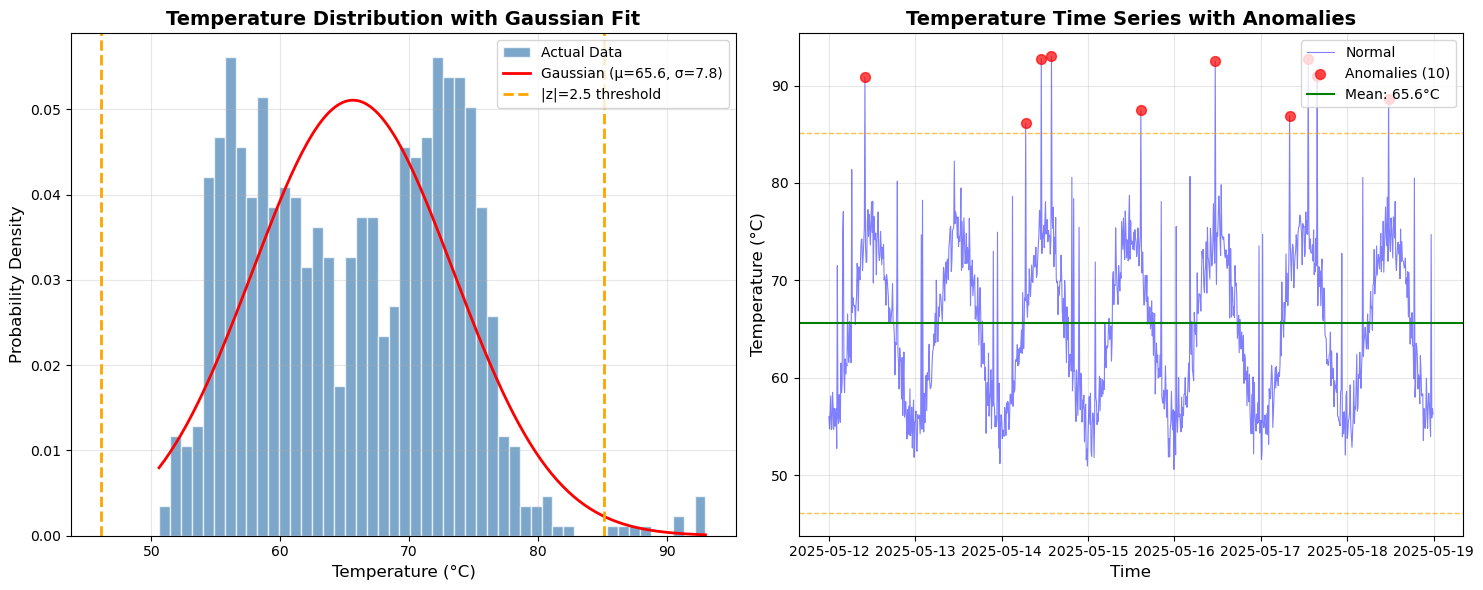

In [12]:
# Cell 3: Plot distribution with Gaussian overlay
def plot_with_gaussian(data, stats_result, anomaly_mask):
    """Plot histogram with fitted Gaussian curve"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left plot: Histogram with Gaussian overlay
    ax1.hist(data, bins=50, density=True, alpha=0.7, color='steelblue', 
             edgecolor='white', label='Actual Data')
    
    # Generate Gaussian curve
    x_range = np.linspace(min(data), max(data), 200)
    gaussian = stats.norm.pdf(x_range, stats_result['mean'], stats_result['std_dev'])
    ax1.plot(x_range, gaussian, 'r-', linewidth=2, label=f'Gaussian (μ={stats_result["mean"]:.1f}, σ={stats_result["std_dev"]:.1f})')
    
    # Highlight anomaly thresholds
    threshold_low = stats_result['mean'] - 2.5 * stats_result['std_dev']
    threshold_high = stats_result['mean'] + 2.5 * stats_result['std_dev']
    ax1.axvline(threshold_low, color='orange', linestyle='--', linewidth=2, label='|z|=2.5 threshold')
    ax1.axvline(threshold_high, color='orange', linestyle='--', linewidth=2)
    
    ax1.set_xlabel('Temperature (°C)', fontsize=12)
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.set_title('Temperature Distribution with Gaussian Fit', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right plot: Time series with anomalies highlighted
    ax2.plot(df['timestamp'], data, 'b-', alpha=0.5, linewidth=0.8, label='Normal')
    
    # Highlight anomalies in red
    anomaly_times = df['timestamp'][anomaly_mask]
    anomaly_values = data[anomaly_mask]
    ax2.scatter(anomaly_times, anomaly_values, c='red', s=50, alpha=0.7, 
                label=f'Anomalies ({anomaly_count})', zorder=5)
    
    # Add horizontal lines for mean and thresholds
    ax2.axhline(stats_result['mean'], color='green', linestyle='-', linewidth=1.5, label=f'Mean: {stats_result["mean"]:.1f}°C')
    ax2.axhline(threshold_low, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax2.axhline(threshold_high, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    
    ax2.set_xlabel('Time', fontsize=12)
    ax2.set_ylabel('Temperature (°C)', fontsize=12)
    ax2.set_title('Temperature Time Series with Anomalies', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run visualisation
data_array = df['temperature_c'].values
plot_with_gaussian(data_array, stats_result, anomaly_mask)

In [13]:
# Cell 4: Compute and display daily statistics
def daily_statistics(df):
    """Calculate statistics per day"""
    daily_stats = []
    
    for day in df['day'].unique():
        day_data = df[df['day'] == day]['temperature_c'].values
        
        daily_stats.append({
            'Day': day,
            'Mean': np.mean(day_data),
            'Std': np.std(day_data),
            'Min': np.min(day_data),
            'Max': np.max(day_data),
            'Anomalies': np.sum(np.abs((day_data - np.mean(day_data)) / np.std(day_data)) > 2.5)
        })
    
    return pd.DataFrame(daily_stats)

daily_df = daily_statistics(df)
print("\n📅 DAILY STATISTICS SUMMARY")
print("="*70)
print(daily_df.to_string(index=False))
print("="*70)

# Weekly summary
print(f"\n📈 WEEKLY SUMMARY:")
print(f"   Overall mean: {stats_result['mean']:.2f}°C")
print(f"   Overall std: {stats_result['std_dev']:.2f}°C")
print(f"   Total anomalies: {anomaly_count}")
print(f"   Hottest day: {daily_df.loc[daily_df['Max'].idxmax(), 'Day']} (max {daily_df['Max'].max():.1f}°C)")
print(f"   Coldest day: {daily_df.loc[daily_df['Min'].idxmin(), 'Day']} (min {daily_df['Min'].min():.1f}°C)")


📅 DAILY STATISTICS SUMMARY
 Day      Mean      Std       Min       Max  Anomalies
  12 65.594357 7.875595 51.823087 90.850564          1
  13 65.621585 7.486603 51.181376 82.242632          0
  14 66.074586 8.215913 50.931053 93.014763          2
  15 65.086738 7.585964 50.587247 87.470292          1
  16 65.546507 7.646686 52.080881 92.505250          1
  17 65.755289 8.177392 51.589181 92.745340          3
  18 65.809045 7.612201 52.844435 88.665495          1

📈 WEEKLY SUMMARY:
   Overall mean: 65.64°C
   Overall std: 7.81°C
   Total anomalies: 10
   Hottest day: 14 (max 93.0°C)
   Coldest day: 15 (min 50.6°C)



📖 UNDERSTANDING Z-SCORES

    What is a Z-score?
    -----------------
    Z = (x - μ) / σ
    
    Where:
    • x = individual data point
    • μ = population mean
    • σ = population standard deviation
    
    Interpretation:
    • |z| < 1: Within 1 standard deviation (68% of data)
    • |z| < 2: Within 2 standard deviations (95% of data)
    • |z| < 3: Within 3 standard deviations (99.7% of data)
    • |z| > 2.5: Considered STATISTICAL ANOMALY
    
    In our analysis:
    • Threshold: |z| > 2.5
    • This captures about 99% of normal data
    • Anything beyond is unlikely to occur by chance
    


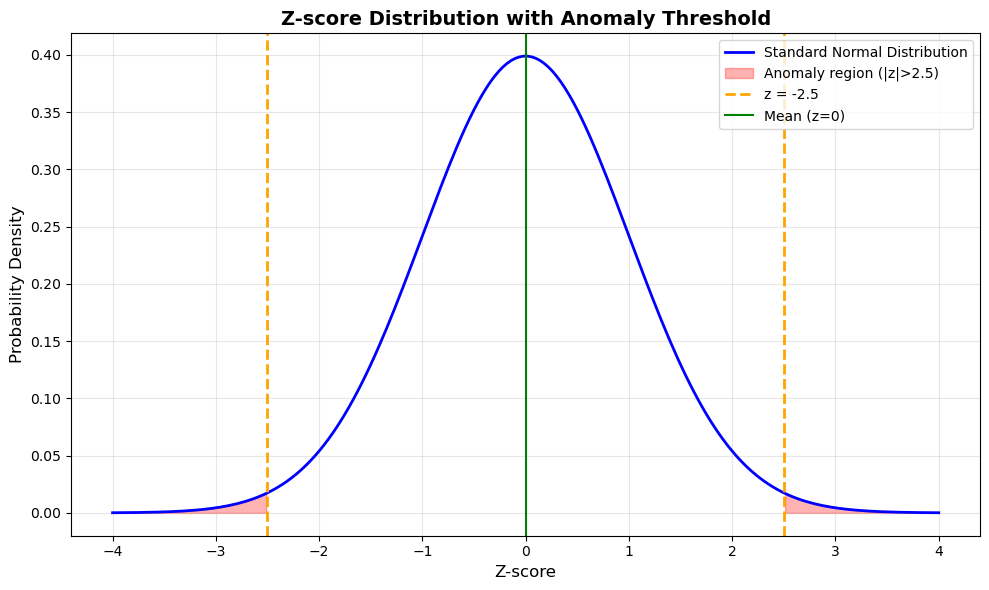

In [14]:
# Cell 5: Explain Z-score concept
def explain_zscore():
    """Educational explanation of Z-scores"""
    
    print("\n" + "="*70)
    print("📖 UNDERSTANDING Z-SCORES")
    print("="*70)
    
    print("""
    What is a Z-score?
    -----------------
    Z = (x - μ) / σ
    
    Where:
    • x = individual data point
    • μ = population mean
    • σ = population standard deviation
    
    Interpretation:
    • |z| < 1: Within 1 standard deviation (68% of data)
    • |z| < 2: Within 2 standard deviations (95% of data)
    • |z| < 3: Within 3 standard deviations (99.7% of data)
    • |z| > 2.5: Considered STATISTICAL ANOMALY
    
    In our analysis:
    • Threshold: |z| > 2.5
    • This captures about 99% of normal data
    • Anything beyond is unlikely to occur by chance
    """)
    
    # Visualise Z-score interpretation
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.linspace(-4, 4, 200)
    y = stats.norm.pdf(x, 0, 1)
    
    ax.plot(x, y, 'b-', linewidth=2, label='Standard Normal Distribution')
    
    # Shade anomaly regions (|z| > 2.5)
    ax.fill_between(x, y, where=(x < -2.5), color='red', alpha=0.3, label='Anomaly region (|z|>2.5)')
    ax.fill_between(x, y, where=(x > 2.5), color='red', alpha=0.3)
    
    # Mark thresholds
    ax.axvline(-2.5, color='orange', linestyle='--', linewidth=2, label='z = -2.5')
    ax.axvline(2.5, color='orange', linestyle='--', linewidth=2)
    ax.axvline(0, color='green', linestyle='-', linewidth=1.5, label='Mean (z=0)')
    
    ax.set_xlabel('Z-score', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.set_title('Z-score Distribution with Anomaly Threshold', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

explain_zscore()